--- Complements (N=100) ---
Nested shares : s1 = 0.5354, w = 0.4444
Budget shares : s1 = 0.5354, s2 = 0.2065, s3 = 0.2581
Max Utility   : 3.4015



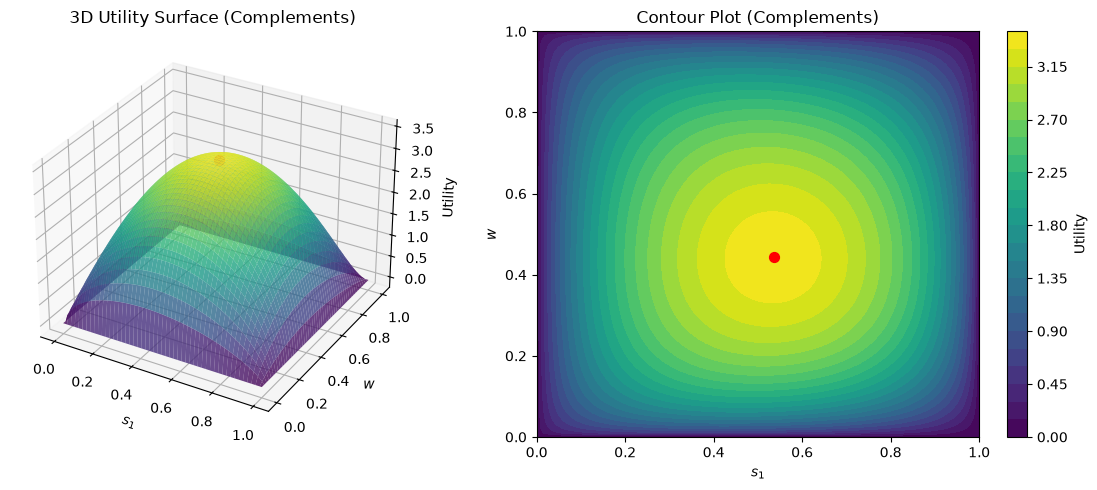

--- Substitutes (N=100) ---
Nested shares : s1 = 0.5354, w = 0.6970
Budget shares : s1 = 0.5354, s2 = 0.3238, s3 = 0.1408
Max Utility   : 3.4850



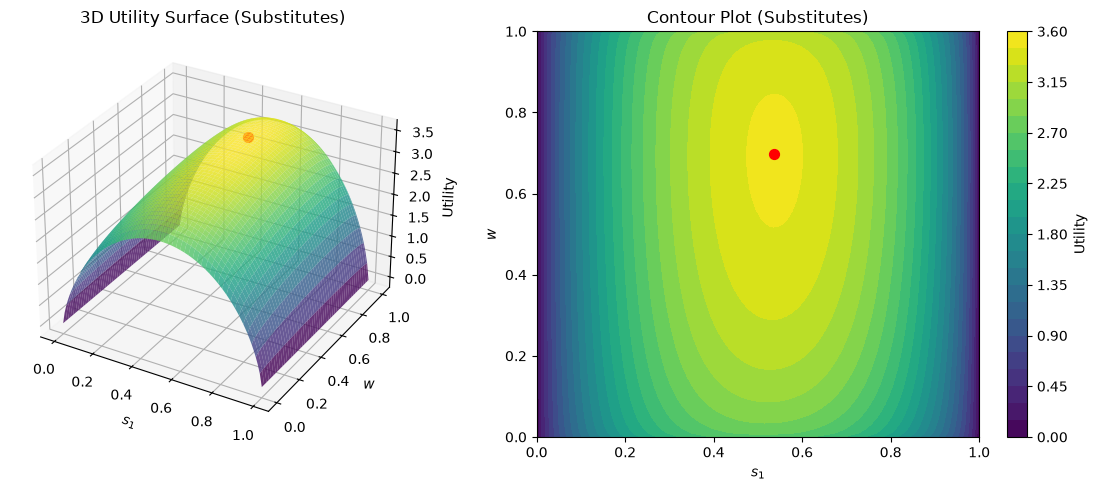

In [1]:
# a. imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
sys.path.append('..') # Fortæller Python at kigge en mappe op
from Consumer import ConsumerClass

# b. setup models
model_comp = ConsumerClass() # Complements
model_sub = ConsumerClass(par={'sigma_B': 3.0}) # Substitutes

# c. function to solve and plot (avoids code repetition)
def solve_and_plot(model, N=100, title=""):
    """ Solves the model using grid search and plots utility in 3D and 2D """
    
    # i. solve the model
    sol = model.solve_grid(N=N, do_print=False)
    
    # ii. print results (s1, w, and implied budget shares)
    print(f"--- {title} (N={N}) ---")
    print(f"Nested shares : s1 = {sol.s1:.4f}, w = {sol.w:.4f}")
    print(f"Budget shares : s1 = {sol.s1:.4f}, s2 = {sol.s2:.4f}, s3 = {sol.s3:.4f}")
    print(f"Max Utility   : {sol.u:.4f}\n")
    
    # iii. setup figure
    fig = plt.figure(figsize=(12, 5))
    
    # iv. 3D surface plot
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    ax3d.plot_surface(sol.s1_grid, sol.w_grid, sol.u_grid, cmap='viridis', alpha=0.8)
    ax3d.scatter(sol.s1, sol.w, sol.u, color='red', s=50, label='Optimum')
    ax3d.set_title(f'3D Utility Surface ({title})')
    ax3d.set_xlabel('$s_1$')
    ax3d.set_ylabel('$w$')
    ax3d.set_zlabel('Utility')
    
    # v. 2D contour plot
    ax_cont = fig.add_subplot(1, 2, 2)
    cs = ax_cont.contourf(sol.s1_grid, sol.w_grid, sol.u_grid, levels=30, cmap='viridis')
    fig.colorbar(cs, ax=ax_cont, label='Utility')
    ax_cont.scatter(sol.s1, sol.w, color='red', s=50, label='Optimum')
    ax_cont.set_title(f'Contour Plot ({title})')
    ax_cont.set_xlabel('$s_1$')
    ax_cont.set_ylabel('$w$')
    
    plt.tight_layout()
    plt.show()

# d. run for both calibrations (Question 1 & 2)
solve_and_plot(model_comp, N=100, title="Complements")
solve_and_plot(model_sub, N=100, title="Substitutes")

In [3]:
# e. test different grid sizes (Question 3)
N_list = [50, 100, 500, 1000]

def test_grid_sizes(model, name):
    """ Tests the grid search for different values of N to check convergence """
    
    print(f"\nConvergence check for {name}:")
    print(f"{'N':<5} | {'Evaluations':<12} | {'s1':<8} | {'w':<8} | {'Utility':<10}")
    print("-" * 55)
    
    for N in N_list:
        sol = model.solve_grid(N=N, do_print=False)
        evals = N * N # Total number of function evaluations
        print(f"{N:<5} | {evals:<12} | {sol.s1:.4f}   | {sol.w:.4f}   | {sol.u:.6f}")

test_grid_sizes(model_comp, "Complements")
test_grid_sizes(model_sub, "Substitutes")


Convergence check for Complements:
N     | Evaluations  | s1       | w        | Utility   
-------------------------------------------------------
50    | 2500         | 0.5306   | 0.4490   | 3.400748
100   | 10000        | 0.5354   | 0.4444   | 3.401482
500   | 250000       | 0.5351   | 0.4389   | 3.401674
1000  | 1000000      | 0.5355   | 0.4394   | 3.401680

Convergence check for Substitutes:
N     | Evaluations  | s1       | w        | Utility   
-------------------------------------------------------
50    | 2500         | 0.5306   | 0.6939   | 3.484594
100   | 10000        | 0.5354   | 0.6970   | 3.485005
500   | 250000       | 0.5391   | 0.6914   | 3.485097
1000  | 1000000      | 0.5385   | 0.6927   | 3.485104
